# Chemistry Dataset EDA

This notebook performs exploratory data analysis (EDA) with visualizations on `chem_excel_final.xlsx`.

## 1. Import Required Libraries

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Inspect the Data

In [8]:
file_path = "chem_excel_final.xlsx"

xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)

# Use the first sheet by default
df = pd.read_excel(file_path, sheet_name=xls.sheet_names[0])

print("\nDataset shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:")
print(df.dtypes)

display(df.head())

Available sheets: ['Sheet1']

Dataset shape: (101, 11)

Columns: ['Unnamed: 0', 'name', 'conc', 'wl(nm)', 'abs', 'photos', 'HEX', 'R', 'G', 'B', 'HSL']

Data types:
Unnamed: 0        str
name              str
conc          float64
wl(nm)        float64
abs           float64
photos            str
HEX               str
R             float64
G             float64
B             float64
HSL               str
dtype: object


,Unnamed: 0,name,conc,wl(nm),abs,photos,HEX,R,G,B,HSL
0,NaN,5ml,0.2,640.0,0.08,Picture,NaN,NaN,NaN,NaN,NaN
1,NaN,5ml,0.4,640.0,0.14,Picture,NaN,NaN,NaN,NaN,NaN
2,NaN,5ml,0.6,640.0,0.21,NaN,#121A1E,18.0,26.0,30.0,"hsl(199, 25%, 9%)"
3,NaN,5ml,0.8,640.0,52.00,NaN,#081018,8.0,16.0,24.0,"hsl(210, 50%, 6%)"
4,NaN,5ml,1.0,640.0,0.33,NaN,#89BBB8,137.0,187.0,184.0,"hsl(176, 26%, 63%)"


## 3. Data Cleaning and Preparation

Duplicate rows before cleanup: 7
Duplicate rows after cleanup: 0

Summary statistics (all columns):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1,1,1ml,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,93,5,5ml,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conc,93.0,NaN,NaN,NaN,3.323118,2.053112,0.2,1.6,3.2,4.75,10.0
wl(nm),93.0,NaN,NaN,NaN,640.0,0.0,640.0,640.0,640.0,640.0,640.0
abs,93.0,NaN,NaN,NaN,1.664624,5.308291,0.08,0.63,1.09,1.69,52.0
photos,2,1,Picture,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HEX,91,90,#0093C9,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R,91.0,NaN,NaN,NaN,41.428571,53.441379,0.0,0.0,8.0,79.5,189.0
G,91.0,NaN,NaN,NaN,151.505495,33.526564,15.0,142.5,159.0,172.0,191.0
B,91.0,NaN,NaN,NaN,177.967033,40.121607,23.0,186.5,191.0,196.0,208.0


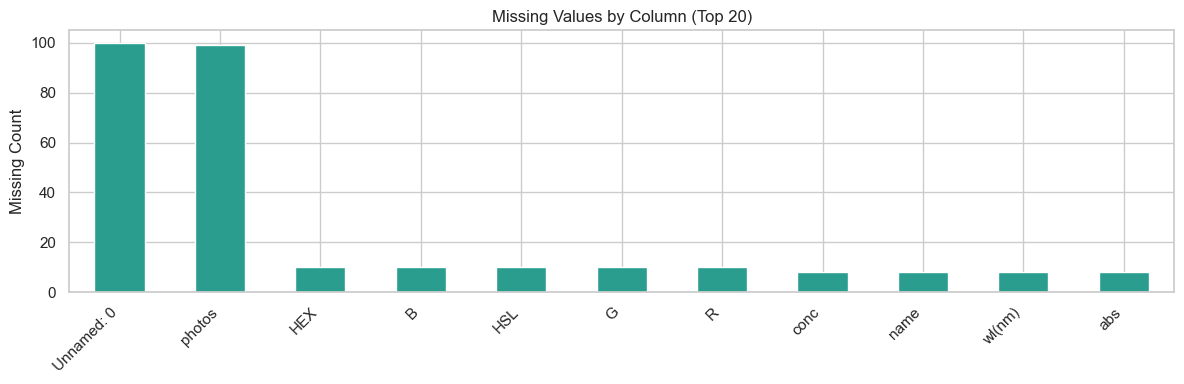

In [9]:
# Missing values overview
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

print(f"Duplicate rows before cleanup: {df.duplicated().sum()}")

# Remove duplicate rows
df = df.drop_duplicates().copy()

print(f"Duplicate rows after cleanup: {df.duplicated().sum()}")

# Try converting object columns to numeric when possible
for col in df.select_dtypes(include="object").columns:
    converted = pd.to_numeric(df[col], errors="coerce")
    if converted.notna().sum() > 0 and converted.notna().sum() >= 0.8 * df[col].notna().sum():
        df[col] = converted

print("\nSummary statistics (all columns):")
display(df.describe(include="all").T)

if len(missing_counts) > 0:
    plt.figure(figsize=(12, 4))
    missing_counts.head(20).plot(kind="bar", color="#2a9d8f")
    plt.title("Missing Values by Column (Top 20)")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

## 4. Univariate Analysis

Numeric columns: ['conc', 'wl(nm)', 'abs', 'R', 'G', 'B']


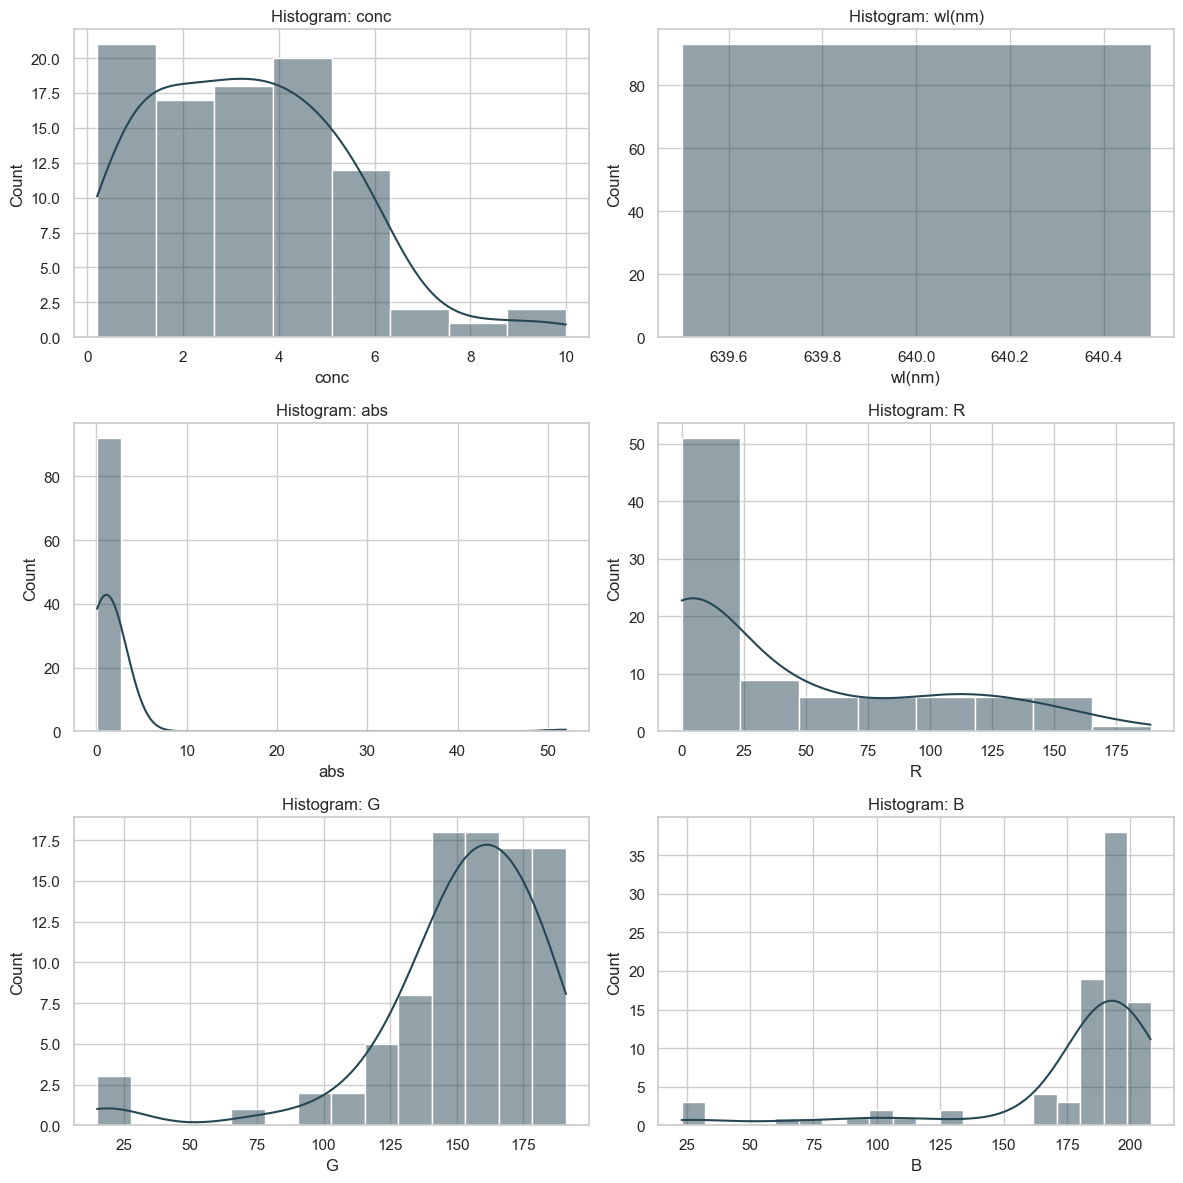

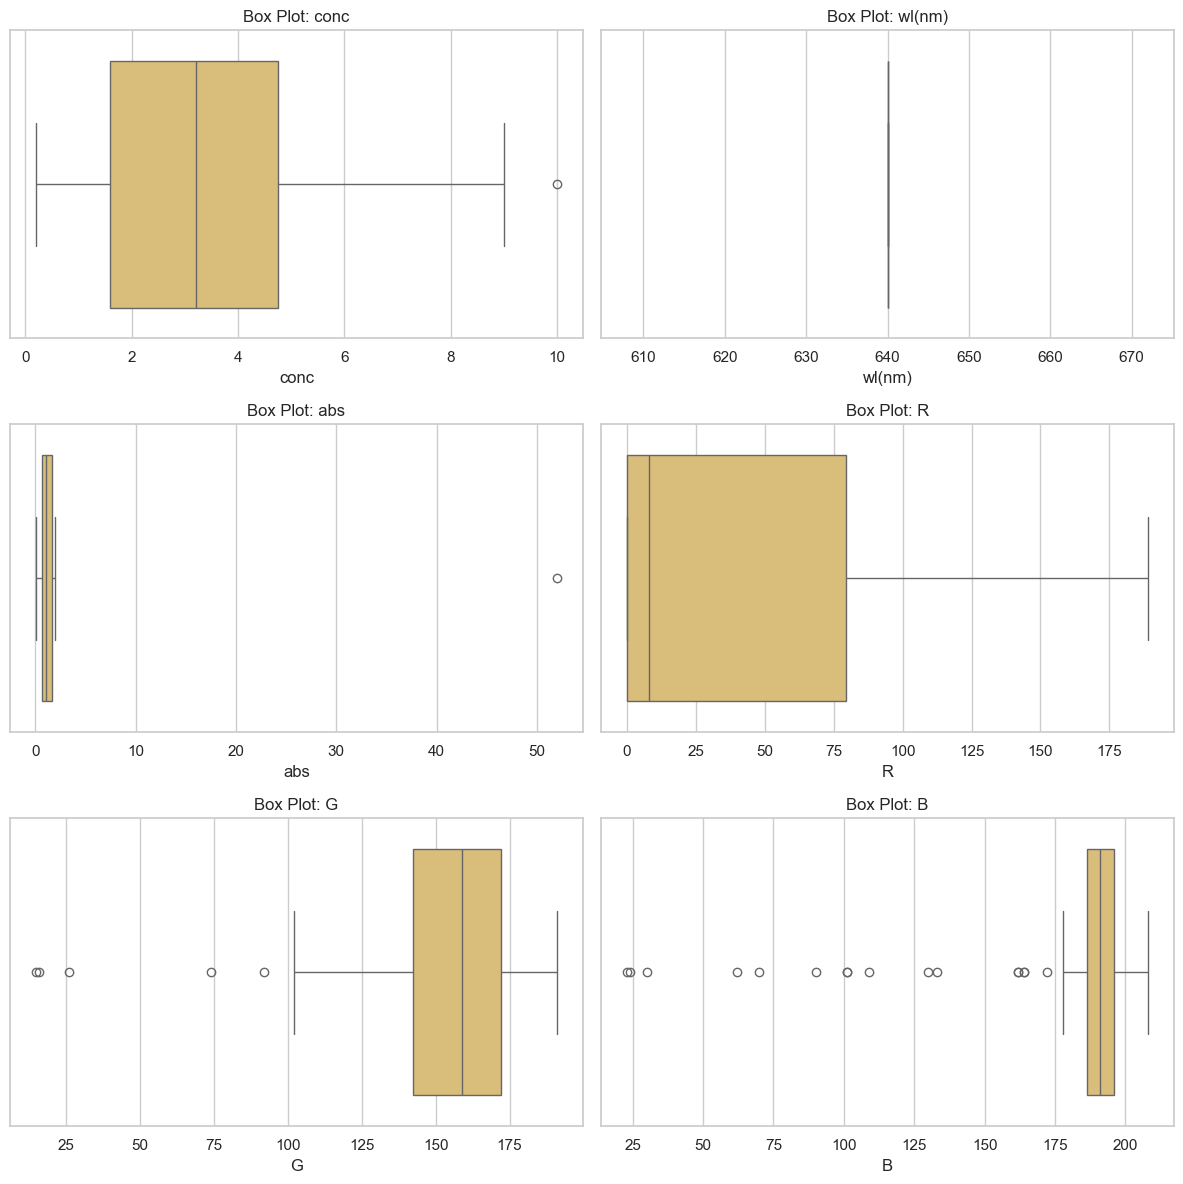

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns:", numeric_cols)

plot_cols = numeric_cols[:8]  # limit for readability

if len(plot_cols) == 0:
    print("No numeric columns available for univariate analysis.")
else:
    # Histograms
    n_cols = 2
    n_rows = int(np.ceil(len(plot_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#264653")
        axes[i].set_title(f"Histogram: {col}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    # Box plots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        sns.boxplot(x=df[col], ax=axes[i], color="#e9c46a")
        axes[i].set_title(f"Box Plot: {col}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

## 5. Bivariate Analysis

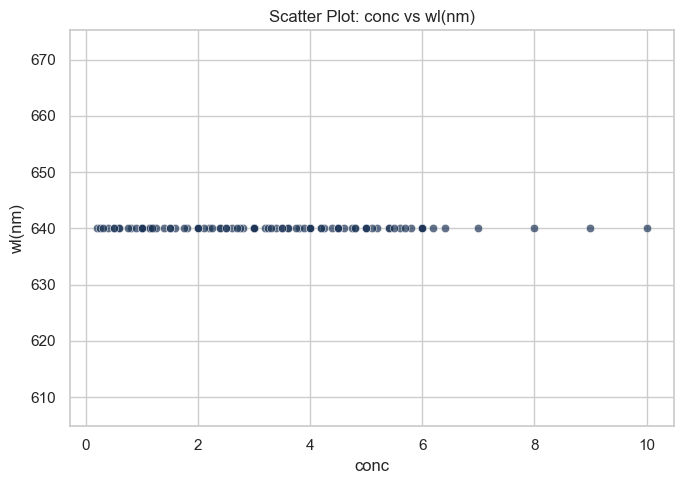

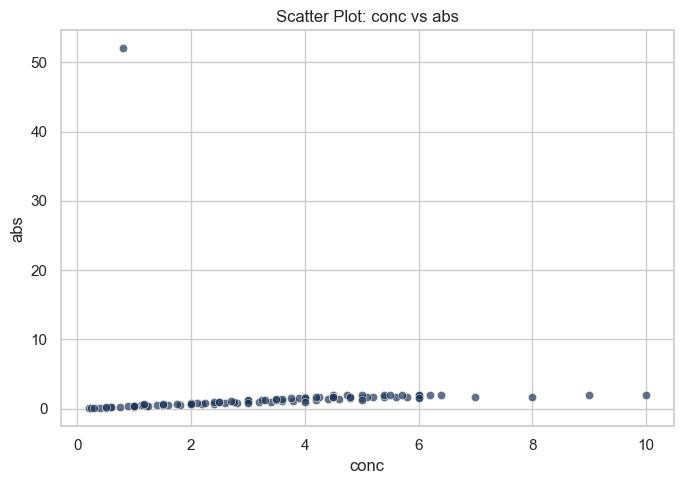

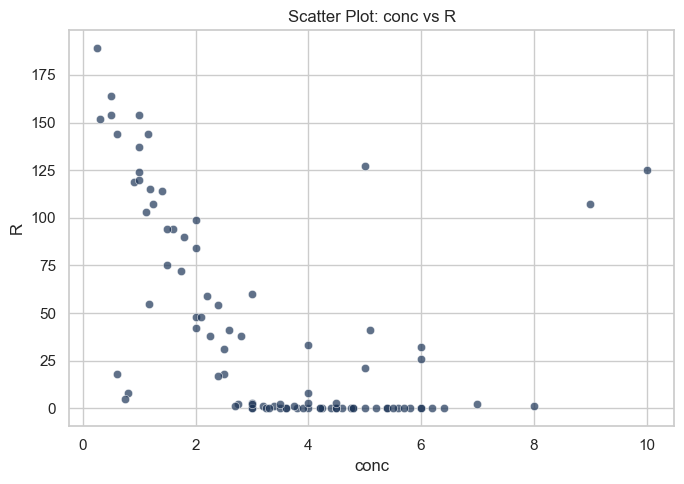

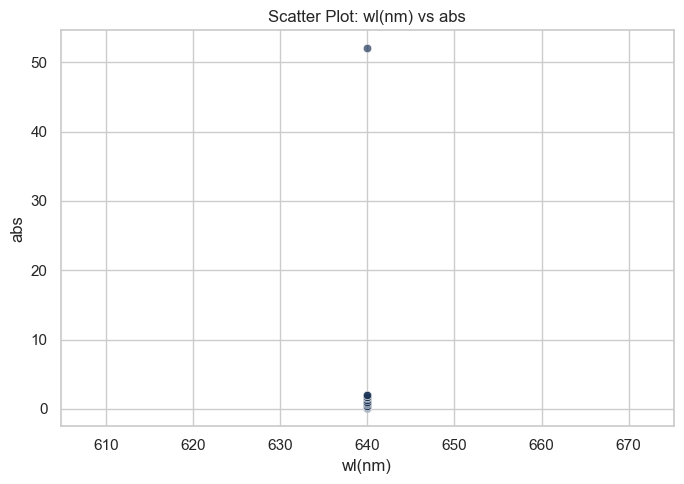

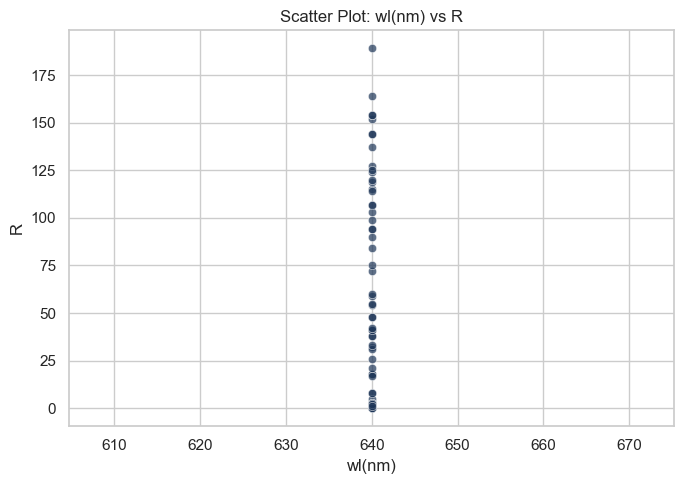

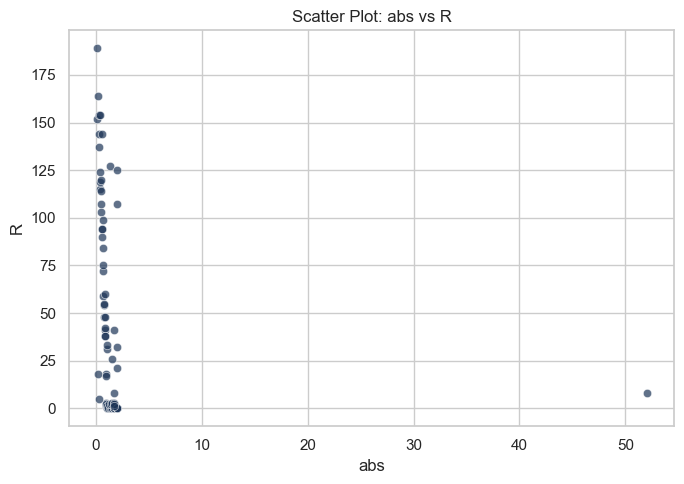

Plotly interactive render skipped (ValueError). Showing static fallback plot.


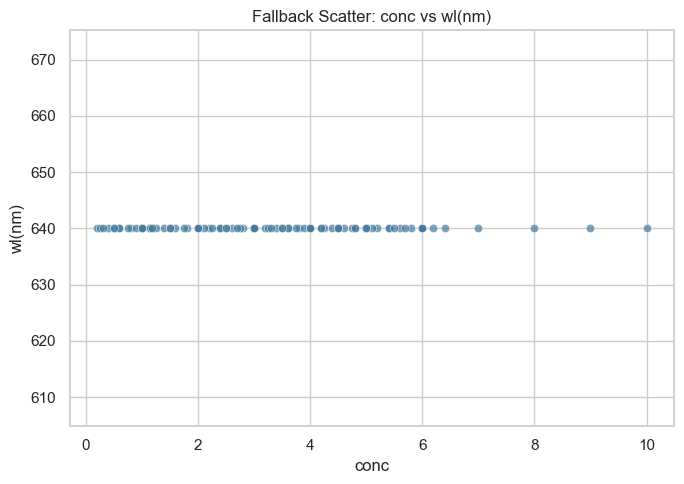

In [11]:
if len(numeric_cols) < 2:
    print("Not enough numeric columns for bivariate scatter plots.")
else:
    pair_candidates = numeric_cols[:4]
    for i in range(len(pair_candidates)):
        for j in range(i + 1, len(pair_candidates)):
            x_col, y_col = pair_candidates[i], pair_candidates[j]
            plt.figure(figsize=(7, 5))
            sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.7, color="#1d3557")
            plt.title(f"Scatter Plot: {x_col} vs {y_col}")
            plt.tight_layout()
            plt.show()

    # Interactive scatter with a safe fallback if notebook mime rendering is unavailable.
    fig = px.scatter(
        df,
        x=pair_candidates[0],
        y=pair_candidates[1],
        title=f"Interactive Scatter: {pair_candidates[0]} vs {pair_candidates[1]}",
        opacity=0.75
    )
    try:
        fig.show()
    except Exception as e:
        print(f"Plotly interactive render skipped ({type(e).__name__}). Showing static fallback plot.")
        plt.figure(figsize=(7, 5))
        sns.scatterplot(data=df, x=pair_candidates[0], y=pair_candidates[1], alpha=0.7, color="#457b9d")
        plt.title(f"Fallback Scatter: {pair_candidates[0]} vs {pair_candidates[1]}")
        plt.tight_layout()
        plt.show()

## 6. Distribution Analysis

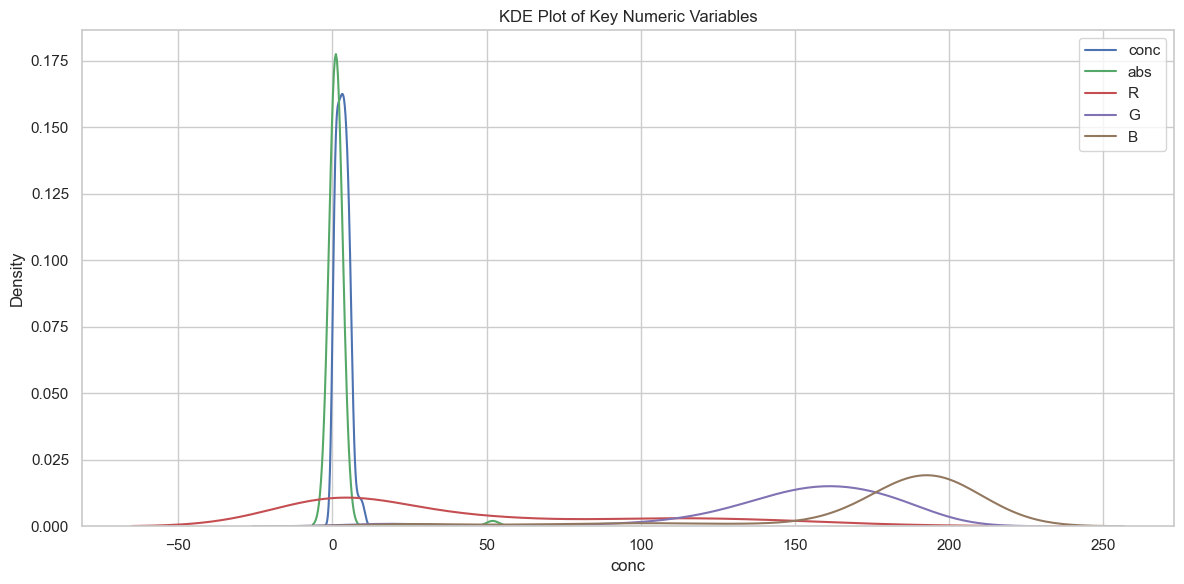

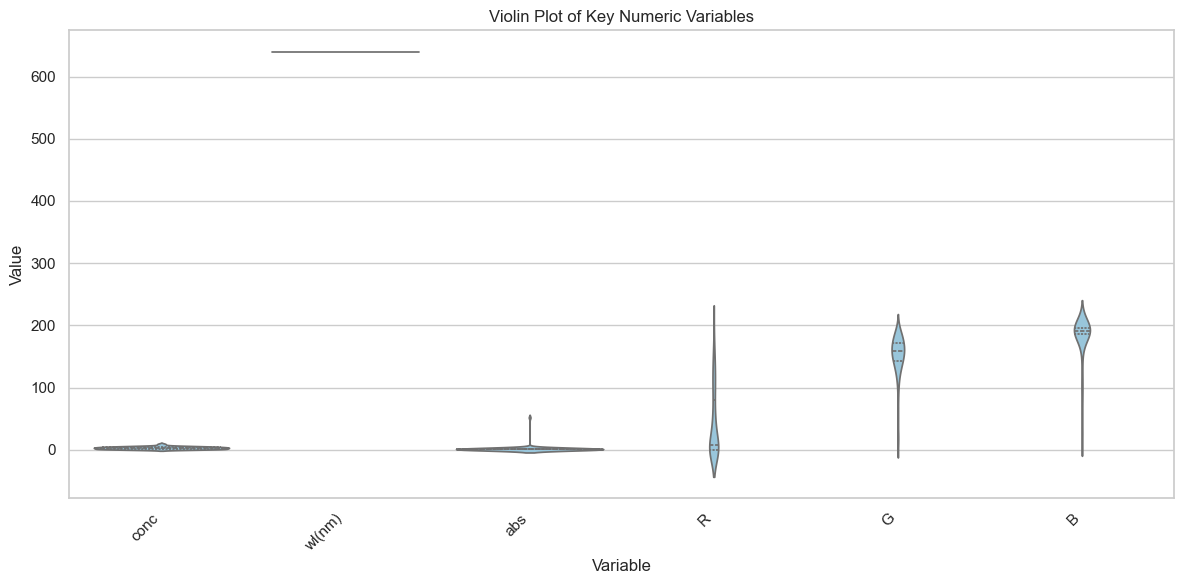

In [12]:
dist_cols = numeric_cols[:6]

if len(dist_cols) == 0:
    print("No numeric columns available for distribution analysis.")
else:
    # KDE plots
    plt.figure(figsize=(12, 6))
    for col in dist_cols:
        sns.kdeplot(df[col].dropna(), label=col, fill=False)
    plt.title("KDE Plot of Key Numeric Variables")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Violin plots
    melted = df[dist_cols].melt(var_name="Variable", value_name="Value")
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=melted, x="Variable", y="Value", inner="quartile", color="#8ecae6")
    plt.title("Violin Plot of Key Numeric Variables")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 7. Correlation Heatmap

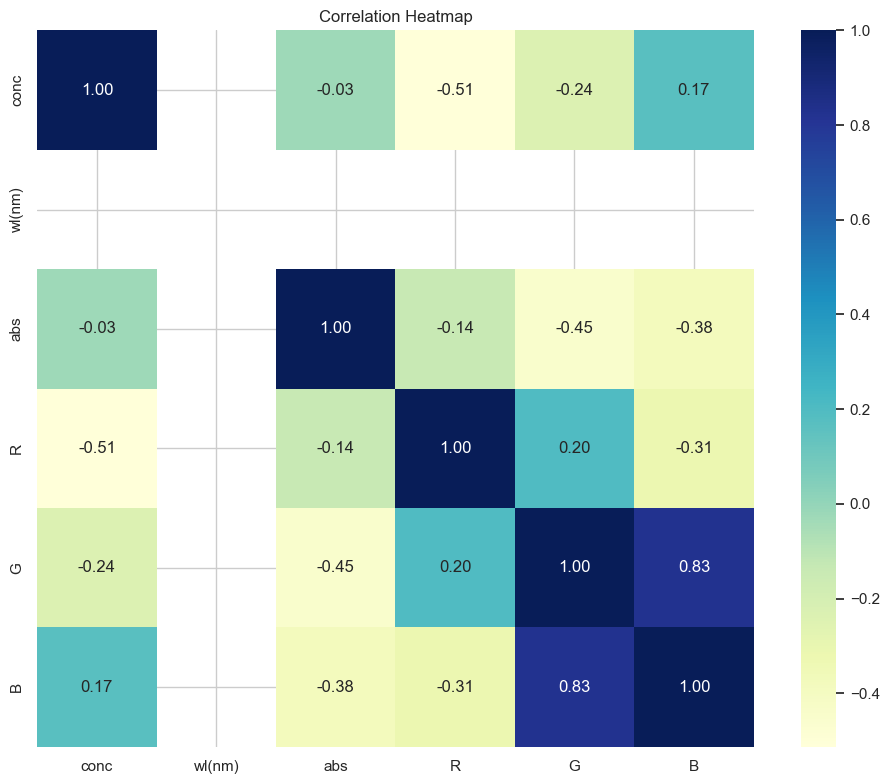

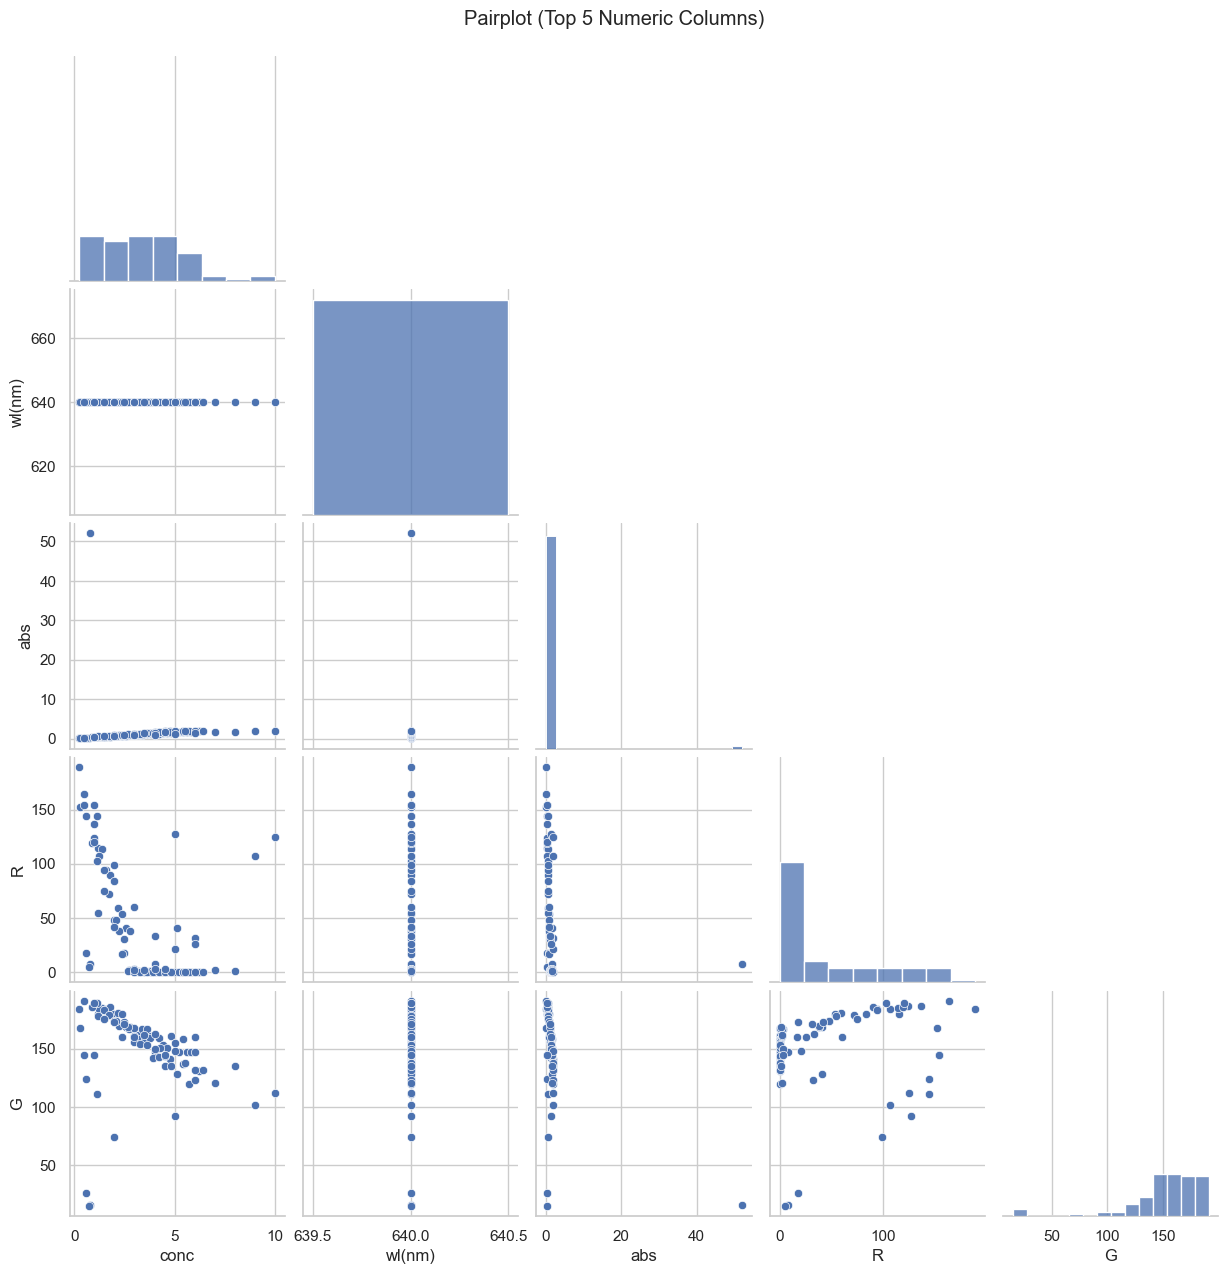

In [13]:
if len(numeric_cols) < 2:
    print("Not enough numeric columns for correlation heatmap.")
else:
    corr = df[numeric_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="YlGnBu", annot=True, fmt=".2f", square=True)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# Optional pairplot (limited)
pairplot_cols = numeric_cols[:5]
if len(pairplot_cols) >= 2:
    sns.pairplot(df[pairplot_cols].dropna(), corner=True)
    plt.suptitle("Pairplot (Top 5 Numeric Columns)", y=1.02)
    plt.show()

In [14]:
# Simple outlier check using IQR
if len(numeric_cols) == 0:
    print("No numeric columns available for outlier check.")
else:
    outlier_summary = []
    for col in numeric_cols:
        s = df[col].dropna()
        if s.empty:
            continue
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_outliers = ((s < lower) | (s > upper)).sum()
        outlier_summary.append({"column": col, "outlier_count": int(n_outliers)})

    outlier_df = pd.DataFrame(outlier_summary).sort_values("outlier_count", ascending=False)
    display(outlier_df)

,column,outlier_count
5,B,16
4,G,5
2,abs,1
0,conc,1
1,wl(nm),0
3,R,0


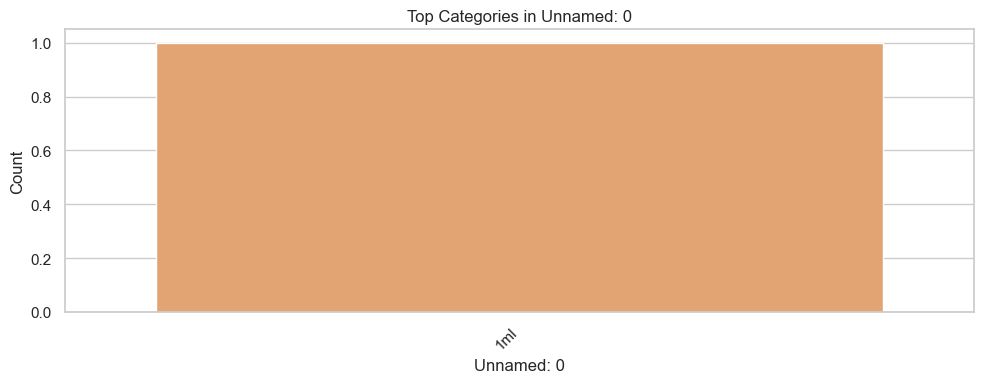

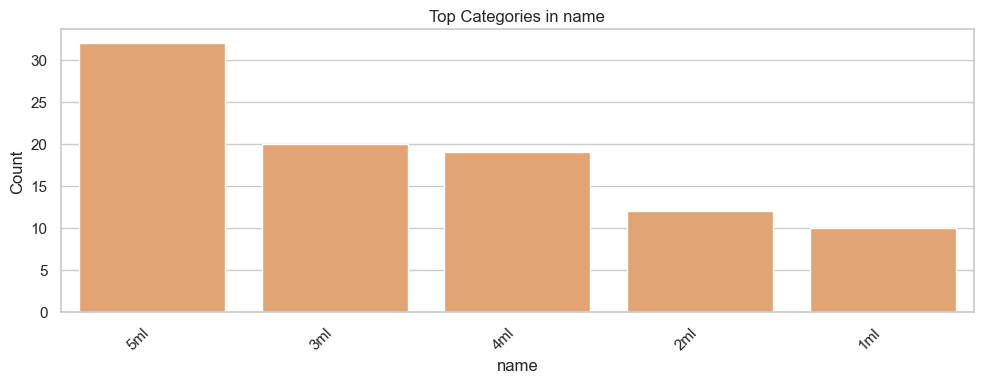

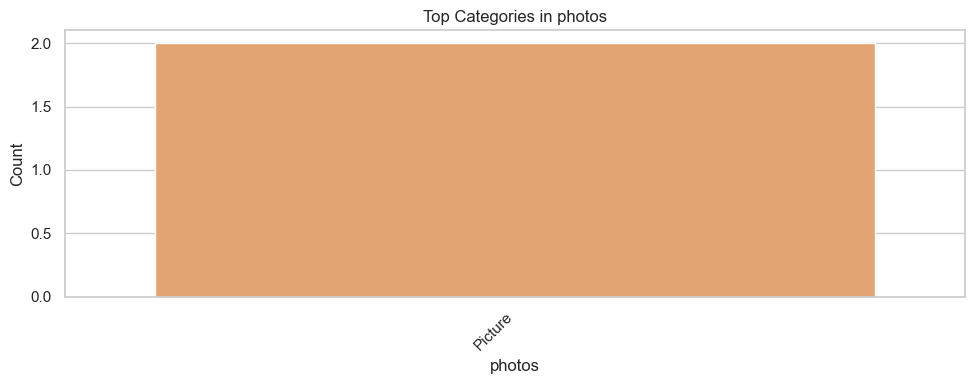

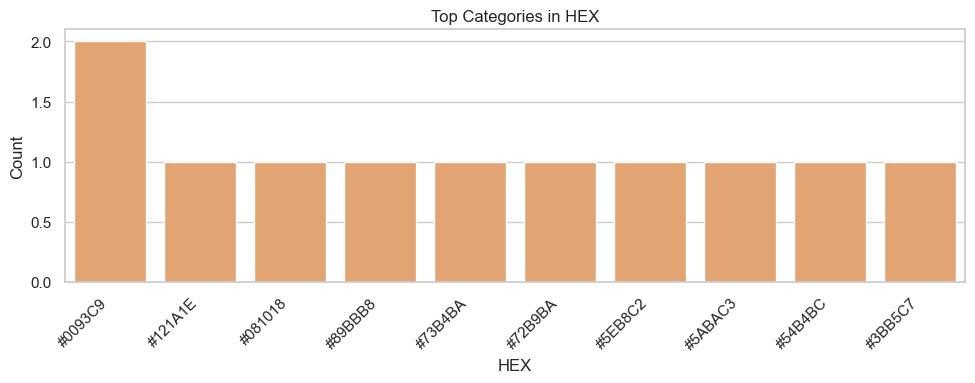

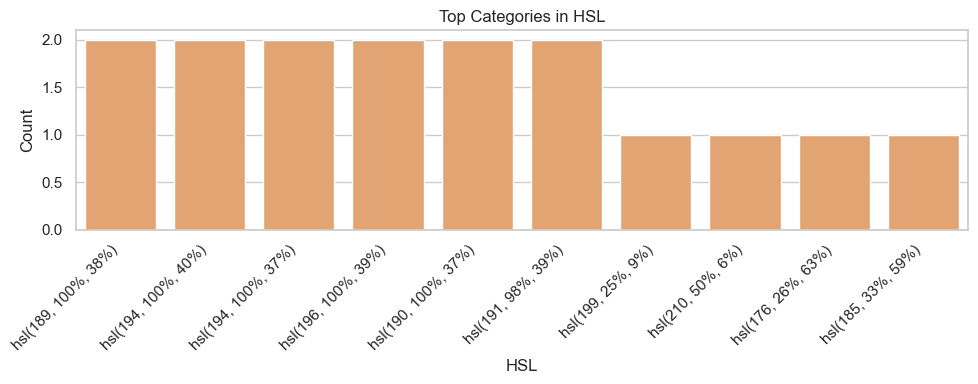

In [15]:
# Optional categorical count plots
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_plot_cols = categorical_cols[:5]

if len(cat_plot_cols) == 0:
    print("No categorical columns found for count plots.")
else:
    for col in cat_plot_cols:
        plt.figure(figsize=(10, 4))
        vc = df[col].astype(str).value_counts().head(10)
        sns.barplot(x=vc.index, y=vc.values, color="#f4a261")
        plt.title(f"Top Categories in {col}")
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

## Summary

- Main observations:
- Potential data quality concerns:
- Next analysis steps: